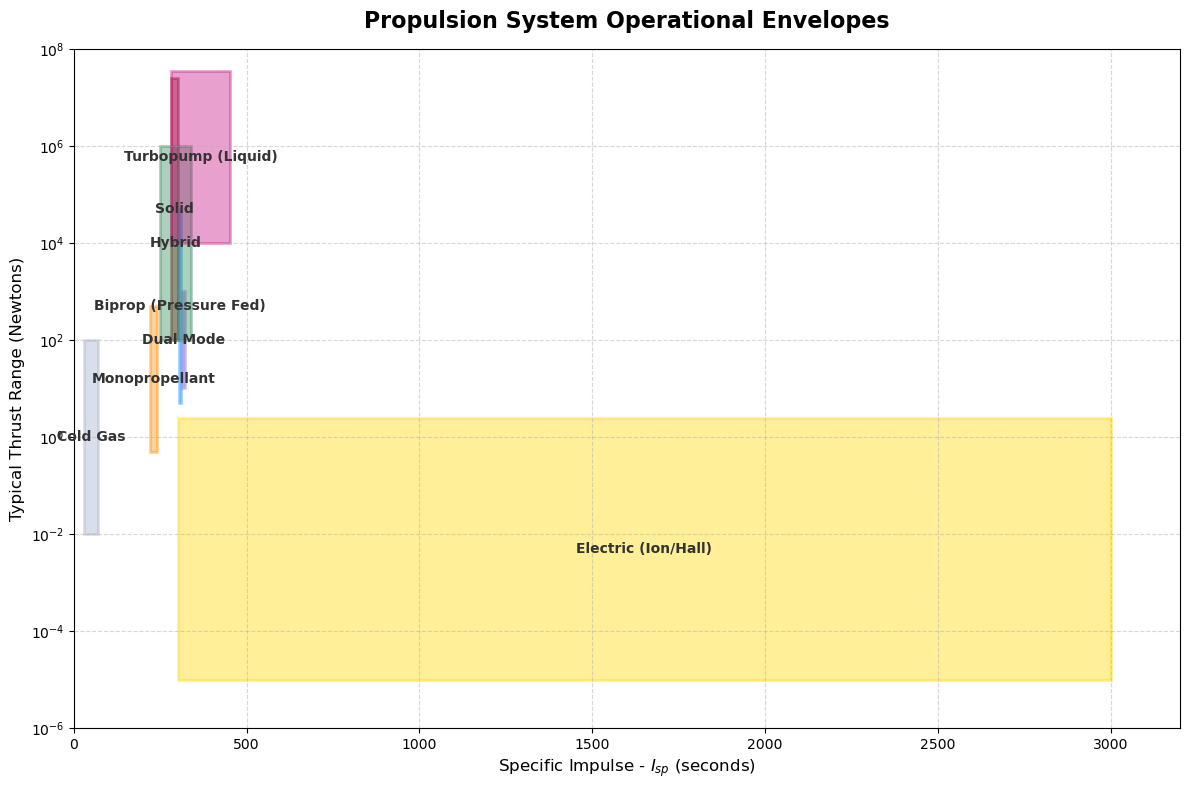

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 8))

# Define the data blobs: [System Name, Isp_min, Isp_max, Thrust_min, Thrust_max, Color]
# Thrust values are in Newtons (N) and estimated to represent typical operational envelopes
propulsion_systems = [
    {"name": "Cold Gas", "isp": (30, 70), "thrust": (0.01, 100), "color": "#A0B0CC"},
    {"name": "Solid", "isp": (280, 300), "thrust": (1e2, 2.5e7), "color": "#8B0000"},
    {"name": "Monopropellant", "isp": (220, 240), "thrust": (0.5, 500), "color": "#FF8C00"},
    {"name": "Biprop (Pressure Fed)", "isp": (305, 310), "thrust": (5, 5e4), "color": "#1E90FF"},
    {"name": "Dual Mode", "isp": (313, 322), "thrust": (10, 1000), "color": "#9370DB"},
    {"name": "Hybrid", "isp": (250, 340), "thrust": (1e2, 1e6), "color": "#2E8B57"},
    {"name": "Electric (Ion/Hall)", "isp": (300, 3000), "thrust": (1e-5, 2.5), "color": "#FFD700"},
    {"name": "Turbopump (Liquid)", "isp": (280, 453), "thrust": (1e4, 3.5e7), "color": "#C71585"}
]

# Plot each blob as a shaded rectangle
for sys in propulsion_systems:
    isp_min, isp_max = sys["isp"]
    t_min, t_max = sys["thrust"]
    
    # Calculate width and height of the blob
    width = isp_max - isp_min
    height = t_max - t_min
    
    # Create the rectangle patch
    rect = patches.Rectangle(
        (isp_min, t_min), width, height,
        linewidth=2, edgecolor=sys["color"], facecolor=sys["color"], alpha=0.4,
        label=sys["name"]
    )
    ax.add_patch(rect)
    
    # Add a text label inside/near the blob
    # Placing text at the center of the bounding box on a log scale for Y
    center_x = isp_min + (width / 2)
    center_y = 10**((np.log10(t_min) + np.log10(t_max)) / 2)
    ax.text(center_x, center_y, sys["name"], ha='center', va='center', 
            fontsize=10, fontweight='bold', color='#333333')

# Formatting the chart
ax.set_yscale('log')
ax.set_xlim(0, 3200)
# Expanding X-axis slightly to give electric propulsion room to breathe
ax.set_ylim(1e-6, 1e8)

# Labels and Grid
ax.set_title("Propulsion System Operational Envelopes", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Specific Impulse - $I_{sp}$ (seconds)", fontsize=12)
ax.set_ylabel("Typical Thrust Range (Newtons)", fontsize=12)
ax.grid(True, which="both", linestyle='--', alpha=0.5)

# Show the plot
plt.tight_layout()
plt.show()

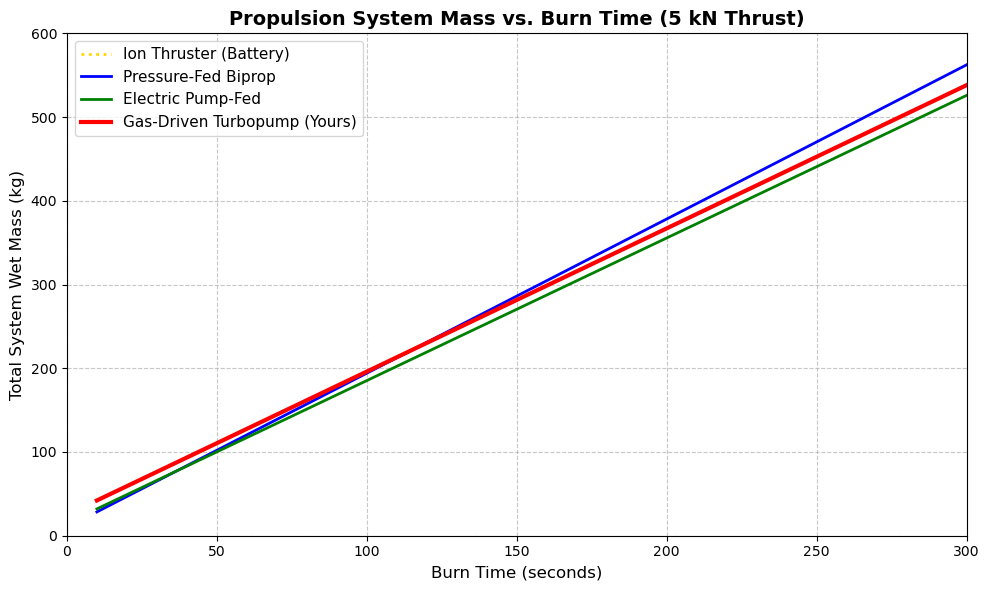

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- System Parameters ---
thrust = 5000.0          # Thrust in Newtons (5 kN)
burn_time = np.linspace(10, 300, 100)  # Burn time in seconds (10s to 5 mins)
g0 = 9.81                # Gravity (m/s^2)

# Specific Impulse (s)
isp_chem = 310.0         # Bipropellant chemical Isp
isp_ion = 2000.0         # Ion thruster Isp

# Mass flow rates (kg/s)
mdot_chem = thrust / (g0 * isp_chem)
mdot_ion = thrust / (g0 * isp_ion)

# Propellant Densities & Tank Fractions (kg of tank per kg of propellant)
rho_prop = 1000.0        # Average bipropellant density (kg/m^3)
tank_frac_high = 0.12    # High-pressure tank penalty (Pressure-fed)
tank_frac_low = 0.02     # Low-pressure tank penalty (Pump-fed / Ion)

# Power & Battery parameters
# Specific energy of space-rated battery (Joules/kg) - approx 150 Wh/kg
e_spec_battery = 150.0 * 3600.0 
delta_p = 3.0e6          # Pump pressure rise (30 bar / 3 MPa)
eta_pump = 0.35          # YOUR low pump efficiency!
eta_ion = 0.60           # Ion thruster electrical efficiency

# --- Fixed Hardware Masses (kg) ---
m_engine_chem = 10.0
m_engine_ion = 20.0
m_pump_electric = 5.0    # Electric motor + pump hardware
m_turbopump = 15.0       # Gas generator turbopump hardware (heavier initially)

# --- Mass Calculations ---

# 1. Ion Thruster (Battery Powered)
# Power = F * g0 * Isp / (2 * eta)
power_ion = (thrust * g0 * isp_ion) / (2 * eta_ion)
m_battery_ion = (power_ion * burn_time) / e_spec_battery
m_prop_ion = mdot_ion * burn_time
m_tank_ion = m_prop_ion * tank_frac_low
m_tot_ion = m_engine_ion + m_battery_ion + m_tank_ion + m_prop_ion

# 2. Pressure-Fed Bipropellant
m_prop_pf = mdot_chem * burn_time
m_tank_pf = m_prop_pf * tank_frac_high
m_tot_pf = m_engine_chem + m_tank_pf + m_prop_pf

# 3. Electric Pump-Fed (EPF)
power_pump = (mdot_chem * delta_p) / (rho_prop * eta_pump)
m_battery_epf = (power_pump * burn_time) / e_spec_battery
m_prop_epf = mdot_chem * burn_time
m_tank_epf = m_prop_epf * tank_frac_low
m_tot_epf = m_engine_chem + m_pump_electric + m_battery_epf + m_tank_epf + m_prop_epf

# 4. Traditional Turbopump (Gas-Driven)
# Assume the gas generator uses 2% extra propellant to drive the turbine
gg_prop_penalty = 1.02 
m_prop_tp = mdot_chem * burn_time * gg_prop_penalty
m_tank_tp = m_prop_tp * tank_frac_low
m_tot_tp = m_engine_chem + m_turbopump + m_tank_tp + m_prop_tp

# --- Plotting ---
plt.figure(figsize=(10, 6))

plt.plot(burn_time, m_tot_ion, label='Ion Thruster (Battery)', color='gold', linewidth=2, linestyle=':')
plt.plot(burn_time, m_tot_pf, label='Pressure-Fed Biprop', color='blue', linewidth=2)
plt.plot(burn_time, m_tot_epf, label='Electric Pump-Fed', color='green', linewidth=2)
plt.plot(burn_time, m_tot_tp, label='Gas-Driven Turbopump (Yours)', color='red', linewidth=3)

# Formatting
plt.title('Propulsion System Mass vs. Burn Time (5 kN Thrust)', fontsize=14, fontweight='bold')
plt.xlabel('Burn Time (seconds)', fontsize=12)
plt.ylabel('Total System Wet Mass (kg)', fontsize=12)
plt.ylim(0, 600) # Capping Y-axis to see the relevant chemical engine crossover
plt.xlim(0, 300)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

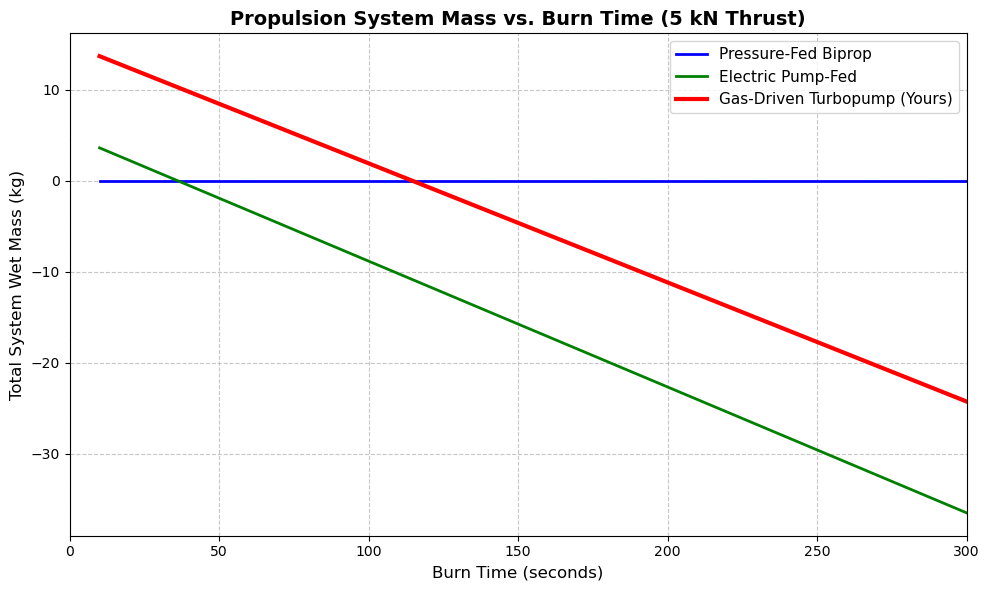

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- System Parameters ---
thrust = 5000.0          # Thrust in Newtons (5 kN)
burn_time = np.linspace(10, 300, 100)  # Burn time in seconds (10s to 5 mins)
g0 = 9.81                # Gravity (m/s^2)

# Specific Impulse (s)
isp_chem = 310.0         # Bipropellant chemical Isp
isp_ion = 2000.0         # Ion thruster Isp

# Mass flow rates (kg/s)
mdot_chem = thrust / (g0 * isp_chem)
mdot_ion = thrust / (g0 * isp_ion)

# Propellant Densities & Tank Fractions (kg of tank per kg of propellant)
rho_prop = 1000.0        # Average bipropellant density (kg/m^3)
tank_frac_high = 0.12    # High-pressure tank penalty (Pressure-fed)
tank_frac_low = 0.02     # Low-pressure tank penalty (Pump-fed / Ion)

# Power & Battery parameters
# Specific energy of space-rated battery (Joules/kg) - approx 150 Wh/kg
e_spec_battery = 150.0 * 3600.0 
delta_p = 3.0e6          # Pump pressure rise (30 bar / 3 MPa)
eta_pump = 0.35          # YOUR low pump efficiency!
eta_ion = 0.60           # Ion thruster electrical efficiency

# --- Fixed Hardware Masses (kg) ---
m_engine_chem = 10.0
m_engine_ion = 20.0
m_pump_electric = 5.0    # Electric motor + pump hardware
m_turbopump = 15.0       # Gas generator turbopump hardware (heavier initially)

# --- Mass Calculations ---

# 1. Ion Thruster (Battery Powered)
# Power = F * g0 * Isp / (2 * eta)
power_ion = (thrust * g0 * isp_ion) / (2 * eta_ion)
m_battery_ion = (power_ion * burn_time) / e_spec_battery
m_prop_ion = mdot_ion * burn_time
m_tank_ion = m_prop_ion * tank_frac_low
m_tot_ion = m_engine_ion + m_battery_ion + m_tank_ion + m_prop_ion

# 2. Pressure-Fed Bipropellant
m_prop_pf = mdot_chem * burn_time
m_tank_pf = m_prop_pf * tank_frac_high
m_tot_pf = m_engine_chem + m_tank_pf + m_prop_pf

# 3. Electric Pump-Fed (EPF)
power_pump = (mdot_chem * delta_p) / (rho_prop * eta_pump)
m_battery_epf = (power_pump * burn_time) / e_spec_battery
m_prop_epf = mdot_chem * burn_time
m_tank_epf = m_prop_epf * tank_frac_low
m_tot_epf = m_engine_chem + m_pump_electric + m_battery_epf + m_tank_epf + m_prop_epf

# 4. Traditional Turbopump (Gas-Driven)
# Assume the gas generator uses 2% extra propellant to drive the turbine
gg_prop_penalty = 1.02 
m_prop_tp = mdot_chem * burn_time * gg_prop_penalty
m_tank_tp = m_prop_tp * tank_frac_low
m_tot_tp = m_engine_chem + m_turbopump + m_tank_tp + m_prop_tp

# --- Plotting ---
plt.figure(figsize=(10, 6))

# plt.plot(burn_time, m_tot_ion, label='Ion Thruster (Battery)', color='gold', linewidth=2, linestyle=':')
plt.plot(burn_time, m_tot_pf - m_tot_pf, label='Pressure-Fed Biprop', color='blue', linewidth=2)
plt.plot(burn_time, m_tot_epf - m_tot_pf, label='Electric Pump-Fed', color='green', linewidth=2)
plt.plot(burn_time, m_tot_tp - m_tot_pf, label='Gas-Driven Turbopump (Yours)', color='red', linewidth=3)

# Formatting
plt.title('Propulsion System Mass vs. Burn Time (5 kN Thrust)', fontsize=14, fontweight='bold')
plt.xlabel('Burn Time (seconds)', fontsize=12)
plt.ylabel('Total System Wet Mass (kg)', fontsize=12)
# plt.ylim(0, 600) # Capping Y-axis to see the relevant chemical engine crossover
plt.xlim(0, 300)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

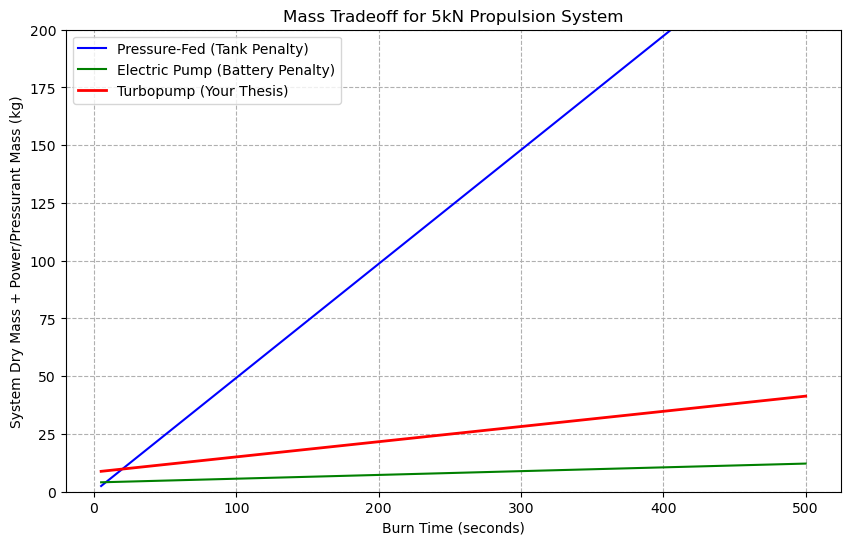

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# --- Mission Parameters ---
thrust = 5000.0  # 5 kN
burn_time = np.linspace(5, 500, 100)
g0 = 9.81
isp = 310.0  # Bipropellant
mdot = thrust / (g0 * isp)

# --- Updated Mass Estimating Relationships (MERs) ---
p_chamber = 3.0e6      # 30 bar
eff_pump = 0.35        # Your specific low Ns pump efficiency
eff_motor = 0.92       # Modern high-end BLDC motor efficiency
e_density_bat = 260 * 3600 # Realistic space-rated battery (J/kg)

# 1. Electric Pump System
# Hardware: Motor (1kg) + Inverter (0.5kg) + Pump (1.5kg) + Wiring (1kg)
m_motor_pump = 4.0     # Fixed dry mass
p_req = (mdot * p_chamber) / (eff_pump * 1000) # Power in Watts (removed /1000 for J/kg consistency)
m_battery = (p_req * burn_time) / (e_density_bat * eff_motor)
m_total_ep = m_motor_pump + m_battery

# 2. Gas Generator Turbopump (Your Thesis)
# Fixed hardware mass is higher due to turbine/GG/valves complexity
m_tp_hardware = 8.5    # Aggressive but realistic 5kN hardware floor
# GG uses ~3-5% propellant mass to drive low-efficiency turbines
mdot_gg = mdot * 0.04  
m_gg_prop = mdot_gg * burn_time
m_total_tp = m_tp_hardware + m_gg_prop

# 3. Pressure-Fed (The Baseline)
# Tank mass is the "killer" here. High pressure requires thick walls
# Using 18% as a realistic penalty for 30-bar tanks + helium systems
tank_weight_penalty = 0.3
m_prop = mdot * burn_time
m_total_pf = m_prop * tank_weight_penalty

# --- Plotting ---
plt.figure(figsize=(10, 6))
plt.plot(burn_time, m_total_pf, label='Pressure-Fed (Tank Penalty)', color='blue')
plt.plot(burn_time, m_total_ep, label='Electric Pump (Battery Penalty)', color='green')
plt.plot(burn_time, m_total_tp, label='Turbopump (Your Thesis)', color='red', linewidth=2)

plt.xlabel('Burn Time (seconds)')
plt.ylabel('System Dry Mass + Power/Pressurant Mass (kg)')
plt.title('Mass Tradeoff for 5kN Propulsion System')
plt.ylim(0, 200)
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

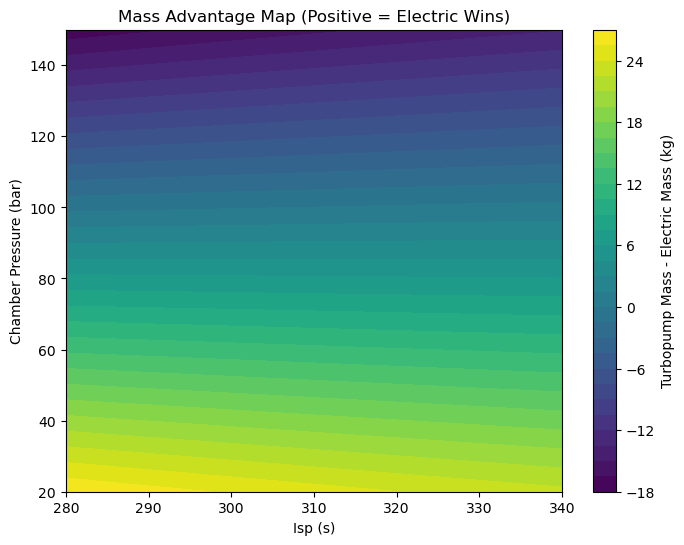

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# --- Constants ---
g0 = 9.81
thrust = 5000.0  # N
burn_time = 400  # fixed burn for crossover comparison

# Prop properties
OF = 2.6
rho_ox = 1140
rho_f = 810

eff_pump = 0.35
eff_motor = 0.92
battery_density = 180 * 3600  # J/kg

# Sweep ranges
pressures = np.linspace(20e5, 150e5, 20)   # 20 to 150 bar
isps = np.linspace(280, 340, 20)

crossover_map = np.zeros((len(pressures), len(isps)))

for i, Pc in enumerate(pressures):
    for j, Isp in enumerate(isps):

        # total mass flow
        mdot = thrust / (g0 * Isp)

        # split flows
        mdot_ox = mdot * OF / (1 + OF)
        mdot_f = mdot / (1 + OF)

        # electric pump power
        P_ox = (mdot_ox / rho_ox) * Pc / eff_pump
        P_f = (mdot_f / rho_f) * Pc / eff_pump

        P_total = P_ox + P_f

        m_battery = (P_total * burn_time) / (battery_density * eff_motor)
        m_electric = 4.0 + m_battery  # hardware + battery

        # turbopump mass
        m_tp_hardware = 8.5
        gg_fraction = 0.04
        m_gg = mdot * gg_fraction * burn_time
        m_turbo = m_tp_hardware + m_gg

        crossover_map[i, j] = m_turbo - m_electric

# Plot contour
plt.figure(figsize=(8,6))
plt.contourf(isps, pressures/1e5, crossover_map, levels=30)
plt.colorbar(label='Turbopump Mass - Electric Mass (kg)')
plt.xlabel("Isp (s)")
plt.ylabel("Chamber Pressure (bar)")
plt.title("Mass Advantage Map (Positive = Electric Wins)")
plt.show()

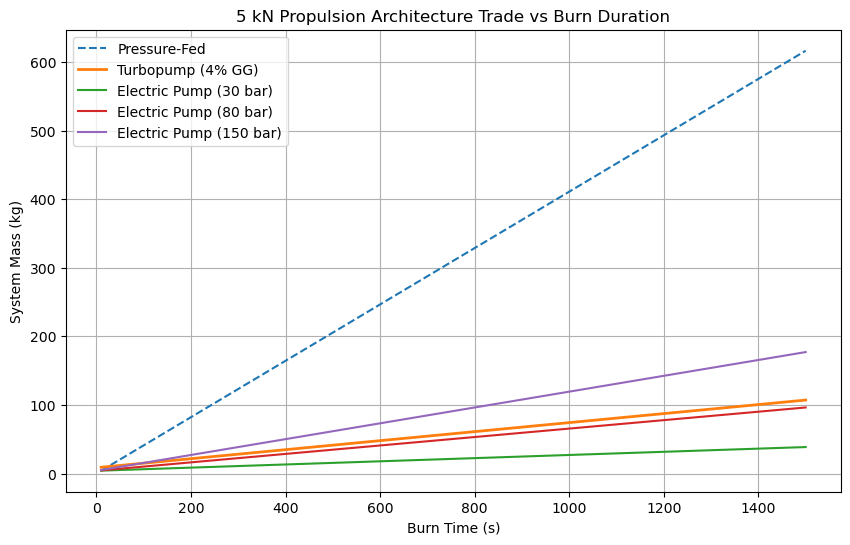

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# --- Constants ---
g0 = 9.81
thrust = 5000.0
burn_time = np.linspace(10, 1500, 300)

Isp = 310
OF = 2.6

rho_ox = 1140
rho_f = 810

eff_pump = 0.35
eff_motor = 0.92
battery_density = 180 * 3600  # J/kg

# --- Mass Flow ---
mdot = thrust / (g0 * Isp)
mdot_ox = mdot * OF / (1 + OF)
mdot_f = mdot / (1 + OF)

# --- Turbopump ---
m_tp_hardware = 8.5
gg_fraction = 0.04
m_turbo = m_tp_hardware + mdot * gg_fraction * burn_time

# --- Pressure-Fed ---
tank_penalty = 0.25
m_prop = mdot * burn_time
m_pressure_fed = tank_penalty * m_prop

# --- Electric Pumps at Different Chamber Pressures ---
pressures = [30e5, 80e5, 150e5]
labels = ["30 bar", "80 bar", "150 bar"]

plt.figure(figsize=(10,6))

# Plot pressure-fed
plt.plot(burn_time, m_pressure_fed, label="Pressure-Fed", linestyle="--")

# Plot turbopump
plt.plot(burn_time, m_turbo, label="Turbopump (4% GG)", linewidth=2)

# Electric variants
for Pc, label in zip(pressures, labels):

    P_ox = (mdot_ox / rho_ox) * Pc / eff_pump
    P_f = (mdot_f / rho_f) * Pc / eff_pump
    P_total = P_ox + P_f

    m_battery = (P_total * burn_time) / (battery_density * eff_motor)
    m_electric = 4.0 + m_battery

    plt.plot(burn_time, m_electric, label=f"Electric Pump ({label})")

plt.xlabel("Burn Time (s)")
plt.ylabel("System Mass (kg)")
plt.title("5 kN Propulsion Architecture Trade vs Burn Duration")
plt.legend()
plt.grid(True)
plt.show()